# 08 — Validasi Kualitas Label Sentimen Awal dan Analisis Distribusi Pseudo-Label

Notebook ini digunakan untuk melakukan validasi awal terhadap hasil pelabelan sentimen komentar YouTube yang telah dibuat pada tahap sebelumnya.

Tahap ini belum bertujuan untuk membangun model machine learning, melainkan untuk memeriksa kualitas pseudo-label sentimen awal yang dihasilkan menggunakan pendekatan lexicon/rule-based.

Label sentimen yang digunakan pada tahap ini terdiri dari:

- positif
- negatif
- netral

## 1. Tujuan Tahap

Tujuan utama tahap ini adalah melakukan validasi kualitas awal terhadap label sentimen yang telah terbentuk pada dataset komentar YouTube.

Secara khusus, tahap ini bertujuan untuk:

1. Memastikan dataset hasil labeling dapat dibaca dengan baik dari folder `data/labeled/`.
2. Memastikan kolom utama yang dibutuhkan tersedia, yaitu `text_original`, `text_clean`, dan `sentiment_label`.
3. Memastikan label sentimen hanya berada pada kategori yang telah ditentukan, yaitu `positif`, `negatif`, dan `netral`.
4. Menganalisis distribusi dan proporsi label sentimen.
5. Menampilkan sampel komentar secara aman dan terbatas untuk membantu validasi kualitas pseudo-label.
6. Mengidentifikasi potensi label yang lemah atau ambigu apabila tersedia kolom skor sentimen.
7. Menyusun catatan keterbatasan pseudo-label sebelum dataset digunakan pada tahap pemodelan machine learning.

## 2. Output yang Dihasilkan

Output yang diharapkan dari notebook ini adalah:

1. Informasi dataset labeled terbaru yang digunakan sebagai input.
2. Hasil validasi keberadaan kolom utama.
3. Ringkasan jumlah data dan struktur dataset secara aman.
4. Ringkasan distribusi label sentimen.
5. Ringkasan proporsi label sentimen.
6. Sampel komentar yang aman, terbatas, dan dipotong panjang teksnya.
7. Visualisasi distribusi label sentimen.
8. Laporan validasi label dalam format file yang disimpan ke folder `reports/`.

Catatan penting:

- Dataset labeled hanya dibaca sebagai input.
- Notebook ini tidak menyimpan ulang dataset komentar penuh.
- Notebook ini tidak membaca file `.env`.
- Notebook ini tidak menampilkan API key.
- Notebook ini tidak menampilkan kolom `author`.
- Dataset pada folder `data/raw/`, `data/processed/`, dan `data/labeled/` tidak boleh dipublikasikan ke GitHub.

## 3. Konsep Validasi Pseudo-Label

Pseudo-label adalah label sementara yang dihasilkan secara otomatis menggunakan aturan tertentu, misalnya pendekatan lexicon-based atau rule-based.

Dalam project ini, pseudo-label digunakan untuk memberi label awal pada komentar YouTube berdasarkan indikasi kata atau pola tertentu yang diasosiasikan dengan sentimen positif, negatif, atau netral.

Namun, pseudo-label belum dapat dianggap sebagai ground truth final karena masih memiliki beberapa keterbatasan, seperti:

1. Potensi salah klasifikasi akibat konteks kalimat yang kompleks.
2. Kesulitan membaca ironi, sarkasme, atau sindiran.
3. Kemungkinan kata yang sama memiliki makna berbeda tergantung konteks.
4. Komentar pendek atau ambigu dapat sulit diklasifikasikan secara akurat.
5. Komentar campuran dapat mengandung sentimen positif dan negatif secara bersamaan.

Oleh karena itu, validasi pseudo-label perlu dilakukan sebelum dataset digunakan pada tahap modeling machine learning.

In [1]:
# ============================================================
# 08 — Validasi Kualitas Label Sentimen Awal
# Bagian: Import Library
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pengaturan tampilan pandas agar output lebih rapi
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 120)

print("Library berhasil di-import.")

Library berhasil di-import.


## 4. Deteksi Project Root

Pada bagian ini, notebook akan mendeteksi folder utama project secara otomatis.

Project root diperlukan agar proses pembacaan file dapat tetap berjalan meskipun notebook dieksekusi dari folder `notebooks/`.

In [2]:
# ============================================================
# Deteksi Project Root
# ============================================================

def find_project_root(start_path=None):
    """
    Mendeteksi folder utama project berdasarkan keberadaan folder penting.
    
    Folder utama project diasumsikan memiliki struktur minimal:
    - notebooks/
    - data/
    - reports/
    
    Fungsi ini tidak membaca file .env dan tidak mengakses API key.
    """
    if start_path is None:
        current_path = Path.cwd().resolve()
    else:
        current_path = Path(start_path).resolve()
    
    for path in [current_path] + list(current_path.parents):
        has_notebooks = (path / "notebooks").exists()
        has_data = (path / "data").exists()
        
        if has_notebooks and has_data:
            return path
    
    raise FileNotFoundError(
        "Project root tidak ditemukan. Pastikan notebook dijalankan dari dalam folder project."
    )


project_root = find_project_root()

data_labeled_dir = project_root / "data" / "labeled"
reports_dir = project_root / "reports"

# Pastikan folder reports tersedia untuk menyimpan laporan validasi
reports_dir.mkdir(parents=True, exist_ok=True)

print("Project root berhasil dideteksi.")
print("Folder data labeled tersedia:", data_labeled_dir.exists())
print("Folder reports tersedia:", reports_dir.exists())

Project root berhasil dideteksi.
Folder data labeled tersedia: True
Folder reports tersedia: True


Project root berhasil dideteksi apabila folder `data/labeled/` dan `reports/` bernilai `True`.

Jika salah satu bernilai `False`, kemungkinan notebook tidak dijalankan dari struktur folder project yang benar.

## 5. Deteksi Dataset Labeled Terbaru

Dataset yang digunakan pada tahap ini berasal dari folder `data/labeled/`.

Notebook akan mencari file dataset labeled terbaru berdasarkan waktu modifikasi file. Hal ini dilakukan agar proses validasi menggunakan output labeling paling baru dari tahap sebelumnya.

In [3]:
# ============================================================
# Deteksi Dataset Labeled Terbaru
# ============================================================

if not data_labeled_dir.exists():
    raise FileNotFoundError(
        f"Folder data labeled tidak ditemukan: {data_labeled_dir}"
    )

# Ekstensi file yang didukung
supported_extensions = ["*.csv", "*.xlsx", "*.xls", "*.parquet"]

labeled_files = []

for ext in supported_extensions:
    labeled_files.extend(data_labeled_dir.glob(ext))

if len(labeled_files) == 0:
    raise FileNotFoundError(
        "Tidak ditemukan dataset labeled di folder data/labeled/. "
        "Pastikan Tahap 07 sudah berhasil menyimpan dataset hasil labeling."
    )

# Ambil file terbaru berdasarkan waktu modifikasi
latest_labeled_file = max(labeled_files, key=lambda file: file.stat().st_mtime)

latest_modified_time = datetime.fromtimestamp(
    latest_labeled_file.stat().st_mtime
).strftime("%Y-%m-%d %H:%M:%S")

print("Dataset labeled terbaru berhasil ditemukan.")
print("Nama file:", latest_labeled_file.name)
print("Waktu modifikasi:", latest_modified_time)

Dataset labeled terbaru berhasil ditemukan.
Nama file: youtube_comments_labeled_20260529_153650.csv
Waktu modifikasi: 2026-05-29 15:37:10


## 6. Load Dataset Labeled Secara Aman

Pada bagian ini, dataset labeled akan dibaca ke dalam DataFrame.

Hal yang perlu diperhatikan:

- Dataset hanya dibaca sebagai input.
- Notebook tidak membaca file `.env`.
- Notebook tidak menampilkan API key.
- Notebook tidak menampilkan kolom `author`.
- Sampel komentar belum ditampilkan pada bagian ini untuk menjaga keamanan data.

In [4]:
# ============================================================
# Fungsi Load Dataset Labeled
# ============================================================

def load_labeled_dataset(file_path):
    """
    Membaca dataset labeled berdasarkan ekstensi file.
    
    Fungsi ini hanya membaca file dataset dan tidak membaca file .env.
    """
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()
    
    if suffix == ".csv":
        try:
            df = pd.read_csv(file_path, encoding="utf-8-sig", low_memory=False)
        except UnicodeDecodeError:
            df = pd.read_csv(file_path, encoding="latin1", low_memory=False)
    
    elif suffix in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    
    elif suffix == ".parquet":
        df = pd.read_parquet(file_path)
    
    else:
        raise ValueError(
            f"Format file tidak didukung: {suffix}"
        )
    
    return df


df_labeled = load_labeled_dataset(latest_labeled_file)

print("Dataset labeled berhasil dibaca.")
print("Jumlah baris:", df_labeled.shape[0])
print("Jumlah kolom:", df_labeled.shape[1])

Dataset labeled berhasil dibaca.
Jumlah baris: 3670
Jumlah kolom: 24


In [5]:
# ============================================================
# Pemeriksaan Struktur Dataset Secara Aman
# ============================================================

if df_labeled.empty:
    raise ValueError("Dataset labeled terbaca, tetapi isinya kosong.")

# Jangan tampilkan kolom author apabila tersedia
safe_columns = [
    col for col in df_labeled.columns
    if col.lower() != "author"
]

print("Dataset tidak kosong.")
print("Jumlah kolom aman yang dapat ditinjau:", len(safe_columns))
print("Daftar kolom aman:")
print(safe_columns)

Dataset tidak kosong.
Jumlah kolom aman yang dapat ditinjau: 24
Daftar kolom aman:
['video_id', 'video_title', 'video_url', 'channel_title', 'video_published_at', 'comment_id', 'published_at', 'comment_updated_at', 'text_original', 'like_count', 'reply_count', 'crawl_timestamp', 'source_file', 'text_original_char_count', 'text_original_word_count', 'text_clean', 'text_clean_char_count', 'text_clean_word_count', 'char_count_reduction', 'word_count_reduction', 'sentiment_label', 'positive_score', 'negative_score', 'sentiment_score_gap']


## 7. Validasi Kolom Utama

Pada tahap ini dilakukan validasi terhadap tiga kolom utama yang wajib tersedia, yaitu:

1. `text_original`
2. `text_clean`
3. `sentiment_label`

Kolom `text_original` digunakan untuk melihat teks asli secara terbatas apabila diperlukan.

Kolom `text_clean` digunakan sebagai hasil teks yang telah dibersihkan pada tahap preprocessing.

Kolom `sentiment_label` digunakan sebagai label sentimen awal hasil proses pseudo-labeling.

In [6]:
# ============================================================
# Validasi Keberadaan Kolom Utama
# ============================================================

required_columns = [
    "text_original",
    "text_clean",
    "sentiment_label"
]

missing_columns = [
    col for col in required_columns
    if col not in df_labeled.columns
]

if missing_columns:
    raise ValueError(
        f"Validasi gagal. Kolom wajib berikut tidak ditemukan: {missing_columns}"
    )

print("Validasi berhasil.")
print("Seluruh kolom utama tersedia:", required_columns)

Validasi berhasil.
Seluruh kolom utama tersedia: ['text_original', 'text_clean', 'sentiment_label']


In [7]:
# ============================================================
# Validasi Nilai Kosong pada Kolom Utama
# ============================================================

null_summary = df_labeled[required_columns].isna().sum().reset_index()
null_summary.columns = ["kolom", "jumlah_missing"]

empty_string_summary = []

for col in required_columns:
    empty_count = (
        df_labeled[col]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    
    empty_string_summary.append({
        "kolom": col,
        "jumlah_string_kosong": int(empty_count)
    })

empty_string_summary = pd.DataFrame(empty_string_summary)

print("Ringkasan missing value pada kolom utama:")
display(null_summary)

print("Ringkasan string kosong pada kolom utama:")
display(empty_string_summary)

Ringkasan missing value pada kolom utama:


,kolom,jumlah_missing
0,text_original,0
1,text_clean,0
2,sentiment_label,0


Ringkasan string kosong pada kolom utama:


,kolom,jumlah_string_kosong
0,text_original,0
1,text_clean,0
2,sentiment_label,0


## 8. Interpretasi Awal Validasi Kolom

Berdasarkan hasil validasi awal, dataset labeled dapat digunakan untuk tahap validasi pseudo-label apabila:

1. Dataset berhasil dibaca dari folder `data/labeled/`.
2. Dataset tidak kosong.
3. Kolom `text_original`, `text_clean`, dan `sentiment_label` tersedia.
4. Jumlah missing value pada kolom utama relatif rendah atau tidak ada.
5. Tidak terdapat string kosong yang signifikan pada kolom utama.

Jika ditemukan missing value atau string kosong, data tersebut perlu dicatat sebagai keterbatasan kualitas data dan dapat dipertimbangkan untuk dianalisis lebih lanjut sebelum masuk ke tahap modeling.

## 9. Validasi Kategori Label Sentimen

Pada bagian ini dilakukan pemeriksaan terhadap isi kolom `sentiment_label`.

Validasi ini bertujuan untuk memastikan bahwa label sentimen hanya terdiri dari tiga kategori yang telah ditentukan, yaitu:

- `positif`
- `negatif`
- `netral`

Jika ditemukan label di luar kategori tersebut, maka data perlu diperiksa kembali karena dapat menunjukkan adanya inkonsistensi pada proses pseudo-labeling.

In [8]:
# ============================================================
# Validasi Kategori Label Sentimen
# ============================================================

allowed_labels = {"positif", "negatif", "netral"}

# Ambil daftar label unik dari dataset
unique_labels = set(
    df_labeled["sentiment_label"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.lower()
    .unique()
)

# Cek label yang tidak sesuai kategori
invalid_labels = unique_labels - allowed_labels

print("Label unik yang ditemukan:")
print(sorted(unique_labels))

if invalid_labels:
    print("\nValidasi kategori label: GAGAL")
    print("Ditemukan label di luar kategori yang diperbolehkan:")
    print(sorted(invalid_labels))
else:
    print("\nValidasi kategori label: BERHASIL")
    print("Seluruh label hanya terdiri dari kategori: positif, negatif, dan netral.")

Label unik yang ditemukan:
['negatif', 'netral', 'positif']

Validasi kategori label: BERHASIL
Seluruh label hanya terdiri dari kategori: positif, negatif, dan netral.


### Interpretasi Validasi Kategori Label

Jika hasil validasi menunjukkan bahwa label hanya terdiri dari `positif`, `negatif`, dan `netral`, maka struktur label pada dataset dapat dinyatakan konsisten.

Namun, validasi ini belum membuktikan bahwa label sudah benar secara semantik. Validasi ini baru memastikan bahwa kategori label tidak menyimpang dari rancangan klasifikasi awal.

Validasi semantik tetap perlu dilakukan melalui pemeriksaan distribusi label, sampel komentar per label, dan analisis kemungkinan komentar ambigu.

## 10. Analisis Distribusi Label

Analisis distribusi label dilakukan untuk mengetahui jumlah komentar pada setiap kategori sentimen.

Distribusi label penting untuk melihat apakah hasil pseudo-labeling cenderung seimbang atau didominasi oleh salah satu kelas tertentu.

Jika salah satu label terlalu dominan, maka hal tersebut perlu dicatat sebagai potensi bias pada pseudo-label.

In [9]:
# ============================================================
# Analisis Distribusi Label Sentimen
# ============================================================

label_distribution = (
    df_labeled["sentiment_label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .reindex(["positif", "negatif", "netral"], fill_value=0)
    .reset_index()
)

label_distribution.columns = ["sentiment_label", "jumlah_komentar"]

total_comments = int(label_distribution["jumlah_komentar"].sum())

label_distribution["proporsi_persen"] = (
    label_distribution["jumlah_komentar"] / total_comments * 100
).round(2)

print("Total komentar berlabel:", total_comments)
display(label_distribution)

Total komentar berlabel: 3670


,sentiment_label,jumlah_komentar,proporsi_persen
0,positif,608,16.57
1,negatif,637,17.36
2,netral,2425,66.08


### Interpretasi Distribusi Label

Tabel distribusi label menunjukkan jumlah komentar untuk masing-masing kategori sentimen.

Interpretasi awal dapat dilakukan sebagai berikut:

1. Jika label `negatif` memiliki jumlah dominan, hal ini dapat menunjukkan bahwa komentar publik cenderung berisi kekhawatiran, kritik, atau respons negatif terhadap isu pelemahan rupiah dan daya beli masyarakat.
2. Jika label `netral` dominan, hal ini dapat menunjukkan bahwa banyak komentar bersifat informatif, deskriptif, bertanya, atau tidak secara eksplisit memuat sentimen emosional.
3. Jika label `positif` dominan, hal ini dapat menunjukkan adanya komentar yang berisi optimisme, dukungan, atau pandangan positif terhadap kondisi ekonomi atau solusi yang dibahas.

Namun, karena label yang digunakan masih berupa pseudo-label, interpretasi ini harus dilakukan secara hati-hati dan tidak dianggap sebagai kesimpulan final sebelum dilakukan validasi lebih lanjut.

## 11. Analisis Proporsi dan Ketidakseimbangan Label

Selain menghitung jumlah komentar per label, perlu juga dianalisis proporsi setiap label terhadap total data.

Analisis proporsi berguna untuk melihat potensi ketidakseimbangan kelas. Ketidakseimbangan ini penting dicatat karena dapat memengaruhi tahap modeling pada proses berikutnya.

In [10]:
# ============================================================
# Analisis Proporsi dan Dominasi Label
# ============================================================

dominant_label_row = label_distribution.sort_values(
    by="jumlah_komentar", ascending=False
).iloc[0]

dominant_label = dominant_label_row["sentiment_label"]
dominant_count = int(dominant_label_row["jumlah_komentar"])
dominant_percentage = float(dominant_label_row["proporsi_persen"])

minority_label_row = label_distribution.sort_values(
    by="jumlah_komentar", ascending=True
).iloc[0]

minority_label = minority_label_row["sentiment_label"]
minority_count = int(minority_label_row["jumlah_komentar"])
minority_percentage = float(minority_label_row["proporsi_persen"])

imbalance_ratio = round(
    dominant_count / minority_count, 2
) if minority_count > 0 else np.inf

print("Ringkasan proporsi label:")
print(f"Label dominan      : {dominant_label}")
print(f"Jumlah dominan     : {dominant_count}")
print(f"Proporsi dominan   : {dominant_percentage}%")
print()
print(f"Label minoritas    : {minority_label}")
print(f"Jumlah minoritas   : {minority_count}")
print(f"Proporsi minoritas : {minority_percentage}%")
print()
print(f"Rasio dominan terhadap minoritas: {imbalance_ratio}")

Ringkasan proporsi label:
Label dominan      : netral
Jumlah dominan     : 2425
Proporsi dominan   : 66.08%

Label minoritas    : positif
Jumlah minoritas   : 608
Proporsi minoritas : 16.57%

Rasio dominan terhadap minoritas: 3.99


In [11]:
# ============================================================
# Interpretasi Otomatis Ketidakseimbangan Label
# ============================================================

if imbalance_ratio == np.inf:
    imbalance_status = "Terdapat label dengan jumlah 0, sehingga distribusi label sangat tidak seimbang."
elif imbalance_ratio >= 5:
    imbalance_status = "Distribusi label sangat tidak seimbang."
elif imbalance_ratio >= 3:
    imbalance_status = "Distribusi label cukup tidak seimbang."
elif imbalance_ratio >= 2:
    imbalance_status = "Distribusi label agak tidak seimbang."
else:
    imbalance_status = "Distribusi label relatif seimbang."

print("Status distribusi label:")
print(imbalance_status)

Status distribusi label:
Distribusi label cukup tidak seimbang.


### Catatan Akademik

Distribusi pseudo-label tidak hanya dibaca sebagai angka, tetapi juga perlu dianalisis sebagai indikator awal kualitas pelabelan.

Apabila satu label terlalu dominan, terdapat beberapa kemungkinan penyebab:

1. Karakter komentar publik memang cenderung mengarah pada sentimen tertentu.
2. Aturan lexicon/rule-based terlalu sensitif terhadap kata tertentu.
3. Banyak komentar pendek atau ambigu yang masuk ke label tertentu.
4. Kosakata dalam komentar YouTube tidak sepenuhnya tertangkap oleh kamus sentimen.
5. Terdapat konteks sosial, ekonomi, atau sarkasme yang tidak dapat dipahami secara utuh oleh pendekatan rule-based.

Oleh karena itu, distribusi label perlu dilengkapi dengan pemeriksaan sampel komentar pada bagian berikutnya.

## 12. Visualisasi Distribusi Label Sentimen

Visualisasi digunakan untuk membantu membaca pola distribusi label secara lebih intuitif.

Pada bagian ini dibuat grafik batang distribusi label sentimen, kemudian grafik disimpan ke folder `reports/`.

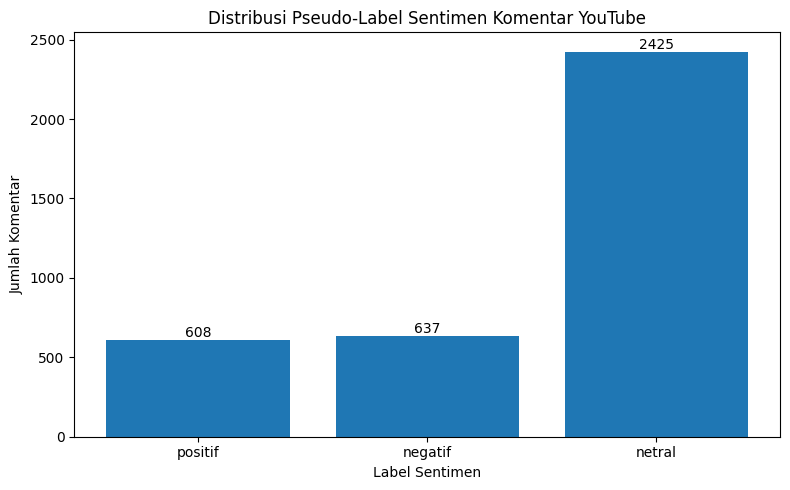

Visualisasi distribusi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_label_distribution_validation_20260529_155228.png


In [12]:
# ============================================================
# Visualisasi Distribusi Label Sentimen
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    label_distribution["sentiment_label"],
    label_distribution["jumlah_komentar"]
)

ax.set_title("Distribusi Pseudo-Label Sentimen Komentar YouTube")
ax.set_xlabel("Label Sentimen")
ax.set_ylabel("Jumlah Komentar")

# Tambahkan angka pada bagian atas bar
for index, row in label_distribution.iterrows():
    ax.text(
        index,
        row["jumlah_komentar"],
        str(row["jumlah_komentar"]),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

label_distribution_chart_path = reports_dir / f"08_label_distribution_validation_{timestamp}.png"
plt.savefig(label_distribution_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Visualisasi distribusi label berhasil disimpan ke:")
print(label_distribution_chart_path)

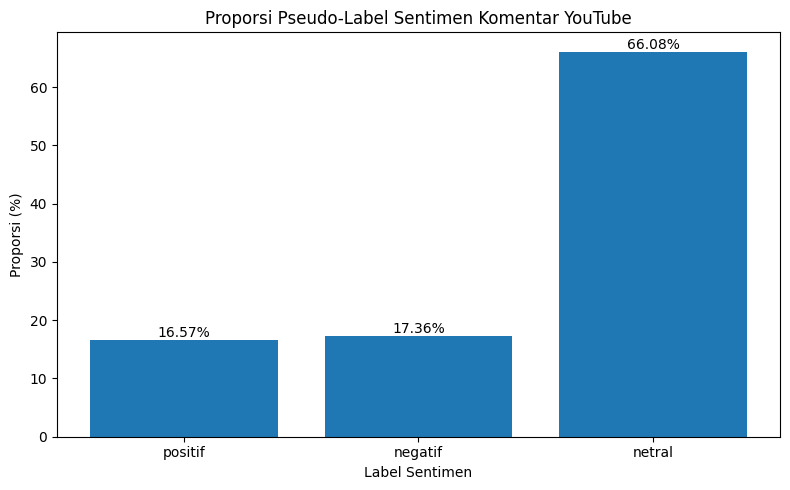

Visualisasi proporsi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_label_proportion_validation_20260529_155228.png


In [13]:
# ============================================================
# Visualisasi Proporsi Label Sentimen
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    label_distribution["sentiment_label"],
    label_distribution["proporsi_persen"]
)

ax.set_title("Proporsi Pseudo-Label Sentimen Komentar YouTube")
ax.set_xlabel("Label Sentimen")
ax.set_ylabel("Proporsi (%)")

# Tambahkan angka persentase pada bagian atas bar
for index, row in label_distribution.iterrows():
    ax.text(
        index,
        row["proporsi_persen"],
        f"{row['proporsi_persen']}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

label_proportion_chart_path = reports_dir / f"08_label_proportion_validation_{timestamp}.png"
plt.savefig(label_proportion_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Visualisasi proporsi label berhasil disimpan ke:")
print(label_proportion_chart_path)

## 13. Penyimpanan Laporan Ringkasan Distribusi Label

Pada bagian ini, ringkasan distribusi label disimpan ke folder `reports/`.

File yang disimpan hanya berupa ringkasan agregat, bukan dataset komentar penuh.

Dengan demikian, file ini aman untuk dokumentasi project dan dapat dipertimbangkan untuk dipush ke GitHub karena tidak memuat komentar asli secara lengkap.

In [14]:
# ============================================================
# Simpan Ringkasan Distribusi Label ke Reports
# ============================================================

label_distribution_report_path = reports_dir / f"08_label_distribution_summary_{timestamp}.csv"

label_distribution.to_csv(
    label_distribution_report_path,
    index=False,
    encoding="utf-8-sig"
)

print("Ringkasan distribusi label berhasil disimpan ke:")
print(label_distribution_report_path)

Ringkasan distribusi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_label_distribution_summary_20260529_155228.csv


In [15]:
# ============================================================
# Simpan Metadata Validasi Awal Label
# ============================================================

validation_metadata = {
    "stage": "08_sentiment_label_validation",
    "description": "Validasi kualitas awal pseudo-label sentimen komentar YouTube",
    "input_file_name": latest_labeled_file.name,
    "input_file_modified_time": latest_modified_time,
    "total_rows": int(df_labeled.shape[0]),
    "total_columns": int(df_labeled.shape[1]),
    "required_columns": required_columns,
    "missing_required_columns": missing_columns,
    "allowed_labels": sorted(list(allowed_labels)),
    "unique_labels_found": sorted(list(unique_labels)),
    "invalid_labels_found": sorted(list(invalid_labels)),
    "total_labeled_comments": total_comments,
    "dominant_label": dominant_label,
    "dominant_count": dominant_count,
    "dominant_percentage": dominant_percentage,
    "minority_label": minority_label,
    "minority_count": minority_count,
    "minority_percentage": minority_percentage,
    "imbalance_ratio": imbalance_ratio,
    "imbalance_status": imbalance_status,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "notes": [
        "Dataset labeled hanya dibaca sebagai input.",
        "Notebook tidak membaca file .env.",
        "Notebook tidak menampilkan API key.",
        "Notebook tidak menampilkan kolom author.",
        "Ringkasan yang disimpan tidak berisi dataset komentar penuh.",
        "Pseudo-label belum dianggap sebagai ground truth final."
    ]
}

metadata_report_path = reports_dir / f"08_label_validation_metadata_{timestamp}.json"

with open(metadata_report_path, "w", encoding="utf-8") as file:
    json.dump(validation_metadata, file, ensure_ascii=False, indent=4)

print("Metadata validasi label berhasil disimpan ke:")
print(metadata_report_path)

Metadata validasi label berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_label_validation_metadata_20260529_155228.json


## 14. Interpretasi Sementara

Berdasarkan validasi kategori dan distribusi label, dataset telah memenuhi struktur dasar untuk digunakan pada tahap analisis lanjutan apabila:

1. Kolom utama tersedia.
2. Label hanya terdiri dari `positif`, `negatif`, dan `netral`.
3. Tidak ditemukan label di luar kategori yang telah ditentukan.
4. Distribusi label berhasil dihitung.
5. Proporsi label berhasil dianalisis.
6. Visualisasi distribusi label berhasil dibuat dan disimpan.
7. Laporan ringkasan distribusi label berhasil disimpan ke folder `reports/`.

Namun, hasil ini belum menunjukkan bahwa label sudah benar secara makna. Oleh karena itu, perlu dilakukan pemeriksaan lanjutan melalui sampel komentar per label dan pemeriksaan komentar ambigu pada bagian berikutnya.

## 15. Sampel Aman Per Label

Setelah distribusi label dianalisis, tahap berikutnya adalah meninjau sampel komentar dari setiap label.

Tujuan pemeriksaan sampel adalah untuk melihat apakah pseudo-label yang diberikan sudah cukup masuk akal secara semantik.

Namun, karena dataset berasal dari komentar YouTube, maka sampel komentar perlu ditampilkan secara aman dengan ketentuan:

1. Tidak menampilkan kolom `author`.
2. Tidak menampilkan komentar dalam jumlah besar.
3. Teks komentar dipotong agar tidak menampilkan komentar secara penuh.
4. Sampel digunakan hanya untuk validasi kualitas label, bukan untuk publikasi dataset komentar penuh.

Pemeriksaan sampel ini penting karena validasi distribusi hanya menunjukkan jumlah label, sedangkan kualitas label perlu dilihat dari kesesuaian antara isi komentar dan label sentimennya.

In [16]:
# ============================================================
# Fungsi Helper untuk Menampilkan Sampel Komentar Secara Aman
# ============================================================

def truncate_text(text, max_length=120):
    """
    Memotong teks agar aman ditampilkan pada notebook.
    
    Fungsi ini digunakan untuk menghindari penampilan komentar secara penuh.
    """
    if pd.isna(text):
        return ""
    
    text = str(text).replace("\n", " ").replace("\r", " ").strip()
    
    if len(text) <= max_length:
        return text
    
    return text[:max_length] + "..."


def create_safe_sample(df, label_col="sentiment_label", labels=None, n_per_label=5):
    """
    Membuat sampel komentar yang aman untuk ditinjau.
    
    Kolom author tidak akan ditampilkan walaupun tersedia di dataset.
    """
    if labels is None:
        labels = ["positif", "negatif", "netral"]
    
    sample_frames = []
    
    for label in labels:
        df_label = df[
            df[label_col]
            .astype(str)
            .str.strip()
            .str.lower()
            .eq(label)
        ].copy()
        
        if len(df_label) == 0:
            continue
        
        sample_size = min(n_per_label, len(df_label))
        
        df_sample = df_label.sample(
            n=sample_size,
            random_state=42
        ).copy()
        
        df_sample["text_original_short"] = df_sample["text_original"].apply(
            lambda x: truncate_text(x, max_length=120)
        )
        
        df_sample["text_clean_short"] = df_sample["text_clean"].apply(
            lambda x: truncate_text(x, max_length=120)
        )
        
        safe_cols = [
            "sentiment_label",
            "text_original_short",
            "text_clean_short"
        ]
        
        sample_frames.append(df_sample[safe_cols])
    
    if len(sample_frames) == 0:
        return pd.DataFrame(
            columns=["sentiment_label", "text_original_short", "text_clean_short"]
        )
    
    return pd.concat(sample_frames, ignore_index=True)


print("Fungsi untuk sampel aman berhasil dibuat.")

Fungsi untuk sampel aman berhasil dibuat.


In [17]:
# ============================================================
# Menampilkan Sampel Aman Per Label
# ============================================================

safe_label_samples = create_safe_sample(
    df=df_labeled,
    label_col="sentiment_label",
    labels=["positif", "negatif", "netral"],
    n_per_label=5
)

print("Sampel aman per label berhasil dibuat.")
print("Jumlah sampel yang ditampilkan:", len(safe_label_samples))

display(safe_label_samples)

Sampel aman per label berhasil dibuat.
Jumlah sampel yang ditampilkan: 15


,sentiment_label,text_original_short,text_clean_short
0,positif,"""situasi begitu bakal bikin investor ragu buat investasi di Indonesia"". Jangankan investor, warga negara nya sendiri...",situasi begitu bakal bikin investor ragu buat investasi di indonesia jangankan investor warga negara nya sendiri saj...
1,positif,Bro bisa meramal keadaan zaman sekarang,bro bisa meramal keadaan zaman sekarang
2,positif,Terimakasih banyak n sdh agk paham... Panjang umur biar ilmunya bisa dibagi..,terimakasih banyak n sudah agk paham panjang umur biar ilmunya bisa dibagi
3,positif,"satu satunya yg bisa disyukurin sebagai pekerja freelance yg dibayar pake dolar, yaa ada kenaikan lumayan pas uangny...",satu satunya yang bisa disyukurin sebagai pekerja freelance yang dibayar pake dolar yaa ada kenaikan lumayan pas uan...
4,positif,Kalau tembus 25.000 tetap optimis karena belum 30.000/50.0000.,kalau tembus 25 000 tetap optimis karena belum 30 000 50 0000
5,negatif,"Capital fligth kita tinggi, korupsi larinya ke singapura. Kebanyakan SDA kita dikontrol luar. Kita diperbudak dollar",capital fligth kita tinggi korupsi larinya ke singapura kebanyakan sda kita dikontrol luar kita diperbudak dollar
6,negatif,"Influencer dan pakar2 keuangan berusaha mengedukasi kita tentang finansial, ngasi kiat2 efektif soal keuangan, eeeeh...",influencer dan pakar2 keuangan berusaha mengedukasi kita tentang finansial ngasi kiat2 efektif soal keuangan eeeehhh...
7,negatif,Tutorial membuat rupiah melemah 1. Lempar pancing ( para investor tanem modal di indonesia ) 2. Siapkan Jaring ( ...,tutorial membuat rupiah melemah 1 lempar pancing para investor tanem modal di indonesia 2 siapkan jaring bikin uu st...
8,negatif,Uang dolar aja gak punya justru ikut sibuk komen dolar naik yg utama bahan pokok tidak naik minyak subsidi tidak naik,uang dolar saja tidak punya justru ikut sibuk komen dolar naik yang utama bahan pokok tidak naik minyak subsidi tida...
9,negatif,Gara Indonesia gk mau pinjam IMF dan gara gara Indonesian deal minyak sama Rusia jadi dimusuhi Amerika sedangkan Mal...,gara indonesia tidak mau pinjam imf dan gara gara indonesian deal minyak sama rusia jadi dimusuhi amerika sedangkan ...


### Panduan Interpretasi Sampel Per Label

Sampel komentar perlu dibaca secara kualitatif untuk melihat apakah label sentimen sudah sesuai dengan isi komentar.

Beberapa hal yang perlu diperhatikan:

1. Komentar berlabel `positif` seharusnya mengandung indikasi dukungan, optimisme, solusi, apresiasi, atau pandangan positif.
2. Komentar berlabel `negatif` seharusnya mengandung kritik, kekhawatiran, keluhan, ketidakpuasan, atau respons negatif.
3. Komentar berlabel `netral` seharusnya cenderung informatif, bertanya, deskriptif, atau tidak memiliki ekspresi sentimen yang kuat.

Jika banyak komentar berlabel `netral` sebenarnya mengandung kritik atau kekhawatiran, maka hal tersebut menunjukkan bahwa pendekatan pseudo-label masih kurang sensitif dalam menangkap makna negatif.

Jika banyak komentar berlabel `positif` atau `negatif` ternyata tidak sesuai secara konteks, maka aturan lexicon/rule-based perlu dicatat sebagai keterbatasan pada laporan.

## 16. Pemeriksaan Kolom Skor Sentimen

Pada tahap labeling sebelumnya, pseudo-label kemungkinan dibuat berdasarkan skor atau aturan tertentu.

Jika dataset memiliki kolom skor sentimen, maka skor tersebut dapat digunakan untuk memeriksa komentar yang memiliki sinyal sentimen lemah atau ambigu.

Komentar dengan skor mendekati nol umumnya perlu diperiksa lebih lanjut karena dapat menunjukkan bahwa komentar tersebut tidak memiliki kecenderungan sentimen yang kuat.

Apabila kolom skor tidak tersedia, maka pemeriksaan komentar ambigu akan dilewati dan dicatat sebagai keterbatasan validasi.

In [18]:
# ============================================================
# Deteksi Kolom Skor Sentimen Jika Tersedia
# ============================================================

# Daftar nama kolom skor yang umum digunakan
preferred_score_columns = [
    "sentiment_score",
    "score_sentiment",
    "lexicon_score",
    "rule_score",
    "polarity_score",
    "compound_score",
    "sentiment_polarity",
    "score"
]

available_score_columns = [
    col for col in preferred_score_columns
    if col in df_labeled.columns
]

# Jika tidak ditemukan dari daftar utama, cari kolom lain yang mengandung kata score/polarity/compound
if len(available_score_columns) == 0:
    candidate_score_columns = []
    
    excluded_keywords = [
        "like",
        "view",
        "comment",
        "reply",
        "author",
        "id"
    ]
    
    for col in df_labeled.columns:
        col_lower = col.lower()
        
        has_score_keyword = (
            "score" in col_lower
            or "polarity" in col_lower
            or "compound" in col_lower
        )
        
        has_excluded_keyword = any(
            keyword in col_lower for keyword in excluded_keywords
        )
        
        if has_score_keyword and not has_excluded_keyword:
            candidate_score_columns.append(col)
    
    available_score_columns = candidate_score_columns

if len(available_score_columns) > 0:
    score_column = available_score_columns[0]
    print("Kolom skor sentimen ditemukan:")
    print(score_column)
else:
    score_column = None
    print("Kolom skor sentimen tidak ditemukan.")
    print("Pemeriksaan komentar ambigu berbasis skor akan dilewati.")

Kolom skor sentimen ditemukan:
positive_score


In [19]:
# ============================================================
# Analisis Statistik Skor Sentimen Jika Tersedia
# ============================================================

if score_column is not None:
    df_labeled[score_column] = pd.to_numeric(
        df_labeled[score_column],
        errors="coerce"
    )
    
    score_summary = df_labeled[score_column].describe().reset_index()
    score_summary.columns = ["statistik", "nilai"]
    
    print("Ringkasan statistik skor sentimen:")
    display(score_summary)
else:
    score_summary = pd.DataFrame()
    print("Analisis statistik skor tidak dilakukan karena kolom skor tidak tersedia.")

Ringkasan statistik skor sentimen:


,statistik,nilai
0,count,3670.000000
1,mean,0.311989
2,std,0.659908
3,min,0.000000
4,25%,0.000000
5,50%,0.000000
6,75%,0.000000
7,max,7.000000


### Interpretasi Statistik Skor Sentimen

Berdasarkan hasil pemeriksaan, kolom skor yang terdeteksi adalah `positive_score`.

Nilai statistik menunjukkan bahwa sebagian besar komentar memiliki skor positif bernilai 0, terlihat dari nilai kuartil 25%, median 50%, dan kuartil 75% yang semuanya bernilai 0. Hal ini menunjukkan bahwa mayoritas komentar tidak mengandung indikator kata positif yang kuat berdasarkan pendekatan lexicon/rule-based.

Namun, `positive_score` tidak dapat langsung dianggap sebagai skor sentimen keseluruhan. Kolom ini hanya merepresentasikan kekuatan atau jumlah indikasi positif dalam komentar. Untuk membaca ambiguitas sentimen secara lebih adil, perlu diperiksa apakah tersedia kolom lain seperti `negative_score`, `neutral_score`, atau `sentiment_score`.

Jika tersedia `positive_score` dan `negative_score`, maka komentar ambigu dapat dianalisis berdasarkan selisih antara skor positif dan negatif. Semakin kecil selisih skor, semakin tinggi kemungkinan komentar tersebut bersifat ambigu atau memiliki sinyal sentimen yang lemah.

In [20]:
# ============================================================
# Pemeriksaan Semua Kolom yang Berkaitan dengan Skor Sentimen
# ============================================================

score_related_columns = [
    col for col in df_labeled.columns
    if "score" in col.lower()
    or "polarity" in col.lower()
    or "compound" in col.lower()
]

print("Kolom terkait skor yang ditemukan:")
print(score_related_columns)

Kolom terkait skor yang ditemukan:
['positive_score', 'negative_score', 'sentiment_score_gap']


In [21]:
# ============================================================
# Deteksi Komentar Ambigu Berdasarkan Skor yang Tersedia
# ============================================================

df_validation = df_labeled.copy()

# Pastikan kolom skor numerik jika tersedia
for col in score_related_columns:
    df_validation[col] = pd.to_numeric(
        df_validation[col],
        errors="coerce"
    ).fillna(0)

has_sentiment_score = "sentiment_score" in df_validation.columns
has_positive_negative_score = (
    "positive_score" in df_validation.columns
    and "negative_score" in df_validation.columns
)

if has_sentiment_score:
    # Jika ada sentiment_score total, gunakan skor total tersebut
    ambiguity_method = "sentiment_score"
    
    df_validation["sentiment_strength"] = df_validation["sentiment_score"].abs()
    
    # Komentar dianggap ambigu jika skor total mendekati 0
    ambiguity_threshold = df_validation["sentiment_strength"].quantile(0.25)
    
    df_ambiguous = df_validation[
        df_validation["sentiment_strength"] <= ambiguity_threshold
    ].copy()

elif has_positive_negative_score:
    # Jika hanya ada positive_score dan negative_score,
    # gunakan selisih keduanya untuk melihat kekuatan arah sentimen
    ambiguity_method = "positive_negative_margin"
    
    df_validation["score_margin"] = (
        df_validation["positive_score"] - df_validation["negative_score"]
    ).abs()
    
    df_validation["sentiment_strength"] = (
        df_validation["positive_score"] + df_validation["negative_score"]
    )
    
    # Komentar dianggap ambigu jika:
    # 1. skor positif dan negatif sama-sama rendah, atau
    # 2. selisih positif-negatif sangat kecil
    df_ambiguous = df_validation[
        (df_validation["sentiment_strength"] == 0)
        | (df_validation["score_margin"] <= 1)
    ].copy()
    
    ambiguity_threshold = 1

elif "positive_score" in df_validation.columns:
    # Fallback: jika hanya ada positive_score,
    # analisis ambigu tidak dianggap kuat karena hanya memakai satu sisi sentimen
    ambiguity_method = "positive_score_only"
    
    df_validation["sentiment_strength"] = df_validation["positive_score"]
    
    df_ambiguous = df_validation[
        df_validation["positive_score"] == 0
    ].copy()
    
    ambiguity_threshold = 0

else:
    ambiguity_method = "no_score_column"
    ambiguity_threshold = None
    df_ambiguous = pd.DataFrame()

ambiguous_count = len(df_ambiguous)
ambiguous_percentage = round(
    ambiguous_count / len(df_validation) * 100, 2
) if len(df_validation) > 0 else 0

print("Metode deteksi ambiguitas:", ambiguity_method)
print("Threshold ambiguitas:", ambiguity_threshold)
print("Jumlah komentar ambigu/lemah:", ambiguous_count)
print("Proporsi komentar ambigu/lemah:", f"{ambiguous_percentage}%")

Metode deteksi ambiguitas: positive_negative_margin
Threshold ambiguitas: 1
Jumlah komentar ambigu/lemah: 3331
Proporsi komentar ambigu/lemah: 90.76%


In [23]:
# ============================================================
# Klasifikasi Kekuatan dan Ambiguitas Sentimen yang Lebih Tepat
# ============================================================

df_validation = df_labeled.copy()

# Pastikan kolom skor tersedia dan numerik
score_columns_needed = ["positive_score", "negative_score"]

for col in score_columns_needed:
    if col not in df_validation.columns:
        raise ValueError(f"Kolom {col} tidak ditemukan pada dataset.")

for col in score_columns_needed:
    df_validation[col] = pd.to_numeric(
        df_validation[col],
        errors="coerce"
    ).fillna(0)

# Hitung total kekuatan sinyal dan margin skor
df_validation["sentiment_strength"] = (
    df_validation["positive_score"] + df_validation["negative_score"]
)

df_validation["score_margin"] = (
    df_validation["positive_score"] - df_validation["negative_score"]
).abs()

# Fungsi klasifikasi status validasi sentimen
def classify_signal_status(row):
    positive_score = row["positive_score"]
    negative_score = row["negative_score"]
    strength = row["sentiment_strength"]
    margin = row["score_margin"]
    
    # Tidak ada sinyal lexicon positif maupun negatif
    if strength == 0:
        return "no_lexicon_signal"
    
    # Ada sinyal positif dan negatif sekaligus, tetapi selisihnya kecil
    if positive_score > 0 and negative_score > 0 and margin <= 1:
        return "mixed_or_ambiguous_signal"
    
    # Hanya satu arah sentimen, tetapi skornya rendah
    if strength <= 1:
        return "weak_single_signal"
    
    # Sinyal sentimen cukup jelas
    return "clearer_signal"


df_validation["signal_status"] = df_validation.apply(
    classify_signal_status,
    axis=1
)

signal_status_summary = (
    df_validation["signal_status"]
    .value_counts()
    .reset_index()
)

signal_status_summary.columns = [
    "signal_status",
    "jumlah_komentar"
]

signal_status_summary["proporsi_persen"] = (
    signal_status_summary["jumlah_komentar"] / len(df_validation) * 100
).round(2)

print("Ringkasan status kekuatan sinyal sentimen:")
display(signal_status_summary)

Ringkasan status kekuatan sinyal sentimen:


,signal_status,jumlah_komentar,proporsi_persen
0,no_lexicon_signal,2277,62.04
1,weak_single_signal,786,21.42
2,clearer_signal,339,9.24
3,mixed_or_ambiguous_signal,268,7.30


In [24]:
# ============================================================
# Pemisahan Komentar Ambigu dan Komentar Bersinyal Lemah
# ============================================================

strict_ambiguous_status = [
    "no_lexicon_signal",
    "mixed_or_ambiguous_signal"
]

weak_signal_status = [
    "weak_single_signal"
]

df_strict_ambiguous = df_validation[
    df_validation["signal_status"].isin(strict_ambiguous_status)
].copy()

df_weak_signal = df_validation[
    df_validation["signal_status"].isin(weak_signal_status)
].copy()

strict_ambiguous_count = len(df_strict_ambiguous)
strict_ambiguous_percentage = round(
    strict_ambiguous_count / len(df_validation) * 100, 2
)

weak_signal_count = len(df_weak_signal)
weak_signal_percentage = round(
    weak_signal_count / len(df_validation) * 100, 2
)

print("Jumlah komentar ambigu ketat:", strict_ambiguous_count)
print("Proporsi komentar ambigu ketat:", f"{strict_ambiguous_percentage}%")
print()
print("Jumlah komentar dengan sinyal lemah:", weak_signal_count)
print("Proporsi komentar dengan sinyal lemah:", f"{weak_signal_percentage}%")

Jumlah komentar ambigu ketat: 2545
Proporsi komentar ambigu ketat: 69.35%

Jumlah komentar dengan sinyal lemah: 786
Proporsi komentar dengan sinyal lemah: 21.42%


In [25]:
# ============================================================
# Sampel Aman Berdasarkan Status Sinyal Sentimen
# ============================================================

sample_signal_frames = []

for status in df_validation["signal_status"].unique():
    df_status = df_validation[
        df_validation["signal_status"] == status
    ].copy()
    
    if len(df_status) == 0:
        continue
    
    sample_size = min(5, len(df_status))
    
    df_sample = df_status.sample(
        n=sample_size,
        random_state=42
    ).copy()
    
    df_sample["text_original_short"] = df_sample["text_original"].apply(
        lambda x: truncate_text(x, max_length=120)
    )
    
    df_sample["text_clean_short"] = df_sample["text_clean"].apply(
        lambda x: truncate_text(x, max_length=120)
    )
    
    safe_cols = [
        "sentiment_label",
        "positive_score",
        "negative_score",
        "score_margin",
        "sentiment_strength",
        "signal_status",
        "text_original_short",
        "text_clean_short"
    ]
    
    sample_signal_frames.append(df_sample[safe_cols])

safe_signal_samples = pd.concat(
    sample_signal_frames,
    ignore_index=True
)

print("Sampel aman berdasarkan status sinyal sentimen:")
display(safe_signal_samples)

Sampel aman berdasarkan status sinyal sentimen:


,sentiment_label,positive_score,negative_score,score_margin,sentiment_strength,signal_status,text_original_short,text_clean_short
0,netral,0,0,0,0,no_lexicon_signal,Mantaaap.. Terimakasih sudah berbagi ilmu👍👍,mantaaap terimakasih sudah berbagi ilmu
1,netral,0,0,0,0,no_lexicon_signal,"288,3 juta jiwa rakyat Indonesia gaada apa yang pengen nggulingin Pak Wo, cape banget tiap denger dia pidato, asbunn...",288 3 juta jiwa rakyat indonesia gaada apa yang pengen nggulingin pak wo cape banget tiap denger dia pidato asbunnya...
2,netral,0,0,0,0,no_lexicon_signal,Siapa yang nonton di 2021,siapa yang nonton di 2021
3,netral,0,0,0,0,no_lexicon_signal,Plot twist yg saling terhubung 🤣🤣🤣😊,plot twist yang saling terhubung
4,netral,0,0,0,0,no_lexicon_signal,Paling stres yg awal pake bahas rank segala,paling stres yang awal pake bahas rank segala
5,negatif,0,1,1,1,weak_single_signal,😊jmn sekarang pda mahal cwe perempuan kekuranggan ekonomi uang kabur ceraii selingkuh bosss😊😊😊😊😊,jmn sekarang pda mahal cwe perempuan kekuranggan ekonomi uang kabur ceraii selingkuh bosss
6,positif,1,0,1,1,weak_single_signal,GILAAAA BISA GINI YAAAA SEREM JUGA,gilaaaa bisa gini yaaaa serem juga
7,positif,1,0,1,1,weak_single_signal,Dollar hasil ekspor tidak semuanya masuk ke Indonesia/ditukar rupiah oleh eksportir tp disimpan di bank luar negeri ...,dollar hasil ekspor tidak semuanya masuk ke indonesia ditukar rupiah oleh eksportir tapi disimpan di bank luar neger...
8,positif,1,0,1,1,weak_single_signal,gapantes banget channel bagus gini subscribenya cuma seribu,gapantes banget channel bagus gini subscribenya cuma seribu
9,positif,1,0,1,1,weak_single_signal,"Min bahas juga dong mengenai MMT (Modern Monetary Theory). Denger2 jaman jerman porak poranda akibat kalah perang, ...",min bahas juga dong mengenai mmt modern monetary theory denger2 jaman jerman porak poranda akibat kalah perang dalam...


In [26]:
# ============================================================
# Simpan Ringkasan Status Sinyal ke Folder Reports
# ============================================================

signal_status_report_path = reports_dir / f"08_signal_status_summary_{timestamp}.csv"

signal_status_summary.to_csv(
    signal_status_report_path,
    index=False,
    encoding="utf-8-sig"
)

print("Ringkasan status sinyal sentimen berhasil disimpan ke:")
print(signal_status_report_path)

Ringkasan status sinyal sentimen berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_signal_status_summary_20260529_155228.csv


In [27]:
# ============================================================
# Simpan Sampel Aman Status Sinyal ke Folder Reports
# ============================================================

safe_signal_samples_report_path = reports_dir / f"08_safe_signal_status_samples_{timestamp}.csv"

safe_signal_samples.to_csv(
    safe_signal_samples_report_path,
    index=False,
    encoding="utf-8-sig"
)

print("Sampel aman status sinyal berhasil disimpan ke:")
print(safe_signal_samples_report_path)

Sampel aman status sinyal berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_safe_signal_status_samples_20260529_155228.csv


Hasil deteksi awal menunjukkan 3.331 komentar atau 90,76% masuk kategori ambigu/lemah berdasarkan metode `positive_negative_margin`. Namun, setelah ditinjau, angka tersebut lebih tepat dipahami sebagai indikasi bahwa sebagian besar komentar memiliki kekuatan sinyal sentimen yang rendah, bukan berarti seluruh komentar tersebut salah label.

Hal ini terjadi karena banyak komentar hanya memiliki satu indikator sentimen kecil, misalnya `negative_score = 1` atau `positive_score = 1`. Komentar seperti ini tetap dapat diberi label positif atau negatif, tetapi tingkat keyakinan labelnya relatif rendah.

Oleh karena itu, validasi pseudo-label perlu membedakan antara komentar yang benar-benar ambigu dan komentar yang hanya memiliki sinyal sentimen lemah. Pemisahan ini penting agar analisis kualitas label menjadi lebih adil dan tidak terlalu menyimpulkan bahwa mayoritas pseudo-label bermasalah.

## 20. Catatan Keterbatasan Pseudo-Label

Label sentimen pada dataset ini masih bersifat pseudo-label, yaitu label awal yang dihasilkan secara otomatis menggunakan pendekatan lexicon/rule-based.

Pseudo-label belum dapat dianggap sebagai ground truth final karena masih memiliki beberapa keterbatasan, antara lain:

1. Pendekatan rule-based belum sepenuhnya mampu memahami konteks kalimat.
2. Komentar YouTube sering menggunakan bahasa informal, singkatan, slang, emotikon, dan ekspresi tidak baku.
3. Sistem dapat kesulitan mengenali sarkasme, sindiran, humor, atau komentar bernada ironi.
4. Komentar pendek dapat memiliki skor sentimen rendah meskipun sebenarnya mengandung opini tertentu.
5. Komentar yang membahas isu ekonomi dapat mengandung sentimen campuran, misalnya kritik terhadap kondisi ekonomi tetapi tetap berisi harapan atau solusi.
6. Dominasi label `netral` dapat menunjukkan bahwa banyak komentar tidak memiliki kata sentimen eksplisit, tetapi juga dapat menunjukkan keterbatasan kamus atau aturan pelabelan.
7. Label positif dan negatif dengan skor rendah perlu diperlakukan sebagai label awal dengan tingkat keyakinan terbatas.

Dengan demikian, hasil pseudo-label pada tahap ini perlu diposisikan sebagai dasar awal untuk analisis berikutnya, bukan sebagai kebenaran final.

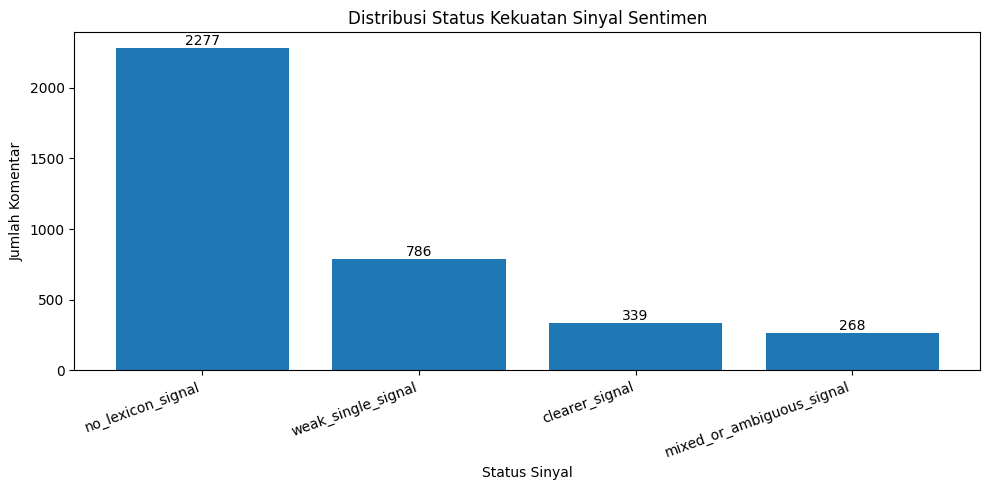

Visualisasi status sinyal sentimen berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_signal_status_distribution_20260529_155228.png


In [28]:
# ============================================================
# Visualisasi Status Sinyal Sentimen
# ============================================================

if "signal_status_summary" in globals() and not signal_status_summary.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.bar(
        signal_status_summary["signal_status"],
        signal_status_summary["jumlah_komentar"]
    )
    
    ax.set_title("Distribusi Status Kekuatan Sinyal Sentimen")
    ax.set_xlabel("Status Sinyal")
    ax.set_ylabel("Jumlah Komentar")
    
    for index, row in signal_status_summary.iterrows():
        ax.text(
            index,
            row["jumlah_komentar"],
            str(row["jumlah_komentar"]),
            ha="center",
            va="bottom"
        )
    
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    
    signal_status_chart_path = reports_dir / f"08_signal_status_distribution_{timestamp}.png"
    plt.savefig(signal_status_chart_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print("Visualisasi status sinyal sentimen berhasil disimpan ke:")
    print(signal_status_chart_path)
else:
    signal_status_chart_path = None
    print("signal_status_summary belum tersedia atau kosong. Visualisasi tidak dibuat.")

## Ringkasan Final Validasi Label

Pada bagian ini disusun ringkasan akhir dari proses validasi pseudo-label.

Ringkasan ini mencakup:

1. Informasi file dataset labeled yang digunakan.
2. Jumlah baris dan kolom dataset.
3. Validasi kolom utama.
4. Validasi kategori label.
5. Distribusi label sentimen.
6. Status ketidakseimbangan label.
7. Status kekuatan sinyal sentimen.
8. Catatan keterbatasan pseudo-label.
9. Rekomendasi tindak lanjut sebelum masuk ke tahap modeling.

In [29]:
# ============================================================
# Final Validation Summary
# ============================================================

final_validation_summary = {
    "stage": "08_sentiment_label_validation",
    "stage_name": "Validasi Kualitas Label Sentimen Awal dan Analisis Distribusi Pseudo-Label",
    "input_dataset": latest_labeled_file.name,
    "input_dataset_modified_time": latest_modified_time,
    "total_rows": int(df_labeled.shape[0]),
    "total_columns": int(df_labeled.shape[1]),
    "required_columns": required_columns,
    "missing_required_columns": missing_columns,
    "allowed_labels": sorted(list(allowed_labels)),
    "unique_labels_found": sorted(list(unique_labels)),
    "invalid_labels_found": sorted(list(invalid_labels)),
    "dominant_label": dominant_label,
    "dominant_count": int(dominant_count),
    "dominant_percentage": float(dominant_percentage),
    "minority_label": minority_label,
    "minority_count": int(minority_count),
    "minority_percentage": float(minority_percentage),
    "imbalance_ratio": float(imbalance_ratio),
    "imbalance_status": imbalance_status,
    "strict_ambiguous_count": int(strict_ambiguous_count) if "strict_ambiguous_count" in globals() else None,
    "strict_ambiguous_percentage": float(strict_ambiguous_percentage) if "strict_ambiguous_percentage" in globals() else None,
    "weak_signal_count": int(weak_signal_count) if "weak_signal_count" in globals() else None,
    "weak_signal_percentage": float(weak_signal_percentage) if "weak_signal_percentage" in globals() else None,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "important_notes": [
        "Pseudo-label belum dianggap sebagai ground truth final.",
        "Distribusi label cukup tidak seimbang apabila rasio dominan terhadap minoritas berada pada kategori cukup tinggi.",
        "Label netral yang dominan perlu dibaca secara hati-hati karena dapat berasal dari komentar yang benar-benar netral atau keterbatasan lexicon/rule-based.",
        "Komentar dengan sinyal sentimen lemah perlu diperiksa sebelum dataset digunakan untuk modeling.",
        "Notebook ini tidak melakukan TF-IDF, train-test split, training model, confusion matrix, atau evaluasi model machine learning.",
        "Dataset komentar penuh tidak disimpan ulang dan tidak dipublikasikan ke GitHub."
    ]
}

print("Ringkasan final validasi berhasil dibuat.")
print(json.dumps(final_validation_summary, indent=4, ensure_ascii=False))

Ringkasan final validasi berhasil dibuat.
{
    "stage": "08_sentiment_label_validation",
    "stage_name": "Validasi Kualitas Label Sentimen Awal dan Analisis Distribusi Pseudo-Label",
    "input_dataset": "youtube_comments_labeled_20260529_153650.csv",
    "input_dataset_modified_time": "2026-05-29 15:37:10",
    "total_rows": 3670,
    "total_columns": 24,
    "required_columns": [
        "text_original",
        "text_clean",
        "sentiment_label"
    ],
    "missing_required_columns": [],
    "allowed_labels": [
        "negatif",
        "netral",
        "positif"
    ],
    "unique_labels_found": [
        "negatif",
        "netral",
        "positif"
    ],
    "invalid_labels_found": [],
    "dominant_label": "netral",
    "dominant_count": 2425,
    "dominant_percentage": 66.08,
    "minority_label": "positif",
    "minority_count": 608,
    "minority_percentage": 16.57,
    "imbalance_ratio": 3.99,
    "imbalance_status": "Distribusi label cukup tidak seimbang.",
    

In [30]:
# ============================================================
# Simpan Laporan Final Validasi ke JSON
# ============================================================

final_validation_json_path = reports_dir / f"08_final_label_validation_summary_{timestamp}.json"

with open(final_validation_json_path, "w", encoding="utf-8") as file:
    json.dump(
        final_validation_summary,
        file,
        ensure_ascii=False,
        indent=4
    )

print("Laporan final validasi JSON berhasil disimpan ke:")
print(final_validation_json_path)

Laporan final validasi JSON berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_final_label_validation_summary_20260529_155228.json


In [33]:
# ============================================================
# Simpan Laporan Final Validasi ke Markdown
# Versi aman tanpa dependency tabulate
# ============================================================

final_validation_md_path = reports_dir / f"08_final_label_validation_report_{timestamp}.md"


def dataframe_to_markdown_manual(df):
    """
    Mengubah DataFrame menjadi tabel Markdown sederhana
    tanpa menggunakan package tabulate.
    """
    if df is None or df.empty:
        return "Data tidak tersedia."
    
    df_temp = df.copy()
    
    # Konversi semua nilai menjadi string dan amankan karakter pipe
    for col in df_temp.columns:
        df_temp[col] = (
            df_temp[col]
            .astype(str)
            .str.replace("|", "/", regex=False)
            .str.replace("\n", " ", regex=False)
            .str.replace("\r", " ", regex=False)
        )
    
    columns = list(df_temp.columns)
    
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    
    rows = []
    for _, row in df_temp.iterrows():
        row_text = "| " + " | ".join([str(row[col]) for col in columns]) + " |"
        rows.append(row_text)
    
    return "\n".join([header, separator] + rows)


label_distribution_md = dataframe_to_markdown_manual(label_distribution)

if "signal_status_summary" in globals() and not signal_status_summary.empty:
    signal_status_md = dataframe_to_markdown_manual(signal_status_summary)
else:
    signal_status_md = "Ringkasan status sinyal tidak tersedia."


markdown_report = f"""# Laporan Validasi Pseudo-Label Sentimen — Tahap 08

## 1. Informasi Dataset

- Nama file input: `{latest_labeled_file.name}`
- Waktu modifikasi file: `{latest_modified_time}`
- Jumlah baris: `{df_labeled.shape[0]}`
- Jumlah kolom: `{df_labeled.shape[1]}`

## 2. Validasi Kolom Utama

Kolom wajib yang diperiksa:

- `text_original`
- `text_clean`
- `sentiment_label`

Hasil validasi:

- Missing required columns: `{missing_columns}`

## 3. Validasi Kategori Label

Kategori label yang diperbolehkan:

- `positif`
- `negatif`
- `netral`

Label unik yang ditemukan:

`{sorted(list(unique_labels))}`

Label tidak valid yang ditemukan:

`{sorted(list(invalid_labels))}`

## 4. Distribusi Label Sentimen

{label_distribution_md}

## 5. Ringkasan Ketidakseimbangan Label

- Label dominan: `{dominant_label}`
- Jumlah label dominan: `{dominant_count}`
- Proporsi label dominan: `{dominant_percentage}%`
- Label minoritas: `{minority_label}`
- Jumlah label minoritas: `{minority_count}`
- Proporsi label minoritas: `{minority_percentage}%`
- Rasio dominan terhadap minoritas: `{imbalance_ratio}`
- Status distribusi: `{imbalance_status}`

## 6. Ringkasan Status Sinyal Sentimen

{signal_status_md}

## 7. Catatan Keterbatasan

Label sentimen pada dataset ini masih berupa pseudo-label yang dihasilkan menggunakan pendekatan lexicon/rule-based. Label tersebut belum dapat dianggap sebagai ground truth final.

Beberapa keterbatasan utama:

1. Sistem belum sepenuhnya memahami konteks kalimat.
2. Komentar YouTube banyak menggunakan bahasa informal, slang, singkatan, dan emotikon.
3. Sarkasme, sindiran, dan ironi sulit dikenali oleh pendekatan rule-based.
4. Komentar pendek dapat memiliki skor sentimen rendah.
5. Dominasi label netral perlu dibaca secara hati-hati.
6. Komentar dengan sinyal sentimen lemah perlu diperlakukan sebagai label dengan tingkat keyakinan terbatas.

## 8. Rekomendasi Tindak Lanjut

1. Melakukan pemeriksaan manual terbatas terhadap sampel komentar.
2. Memeriksa komentar dengan status sinyal lemah atau ambigu.
3. Mengevaluasi ulang lexicon jika ditemukan banyak ketidaksesuaian label.
4. Menjadikan pseudo-label sebagai label awal, bukan ground truth final.
5. Melanjutkan ke tahap persiapan modeling hanya setelah validasi label terdokumentasi.

## 9. Catatan Keamanan Data

Notebook ini tidak membaca file `.env`, tidak menampilkan API key, tidak menampilkan kolom `author`, dan tidak menyimpan ulang dataset komentar penuh.

Folder `data/raw/`, `data/processed/`, dan `data/labeled/` tidak boleh dipublikasikan ke GitHub.
"""

with open(final_validation_md_path, "w", encoding="utf-8") as file:
    file.write(markdown_report)

print("Laporan final validasi Markdown berhasil disimpan ke:")
print(final_validation_md_path)

Laporan final validasi Markdown berhasil disimpan ke:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\08_final_label_validation_report_20260529_155228.md
